In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/fer2013.csv")

print(df.shape)
print(df.columns)
print(df.head())

(35887, 3)
Index(['emotion', 'pixels', 'Usage'], dtype='str')
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


In [10]:
print(df["emotion"].value_counts())

emotion
3    8989
6    6198
4    6077
2    5121
0    4953
5    4002
1     547
Name: count, dtype: int64


shape قبل از reshape: (2304,)
shape بعد از reshape: (48, 48)


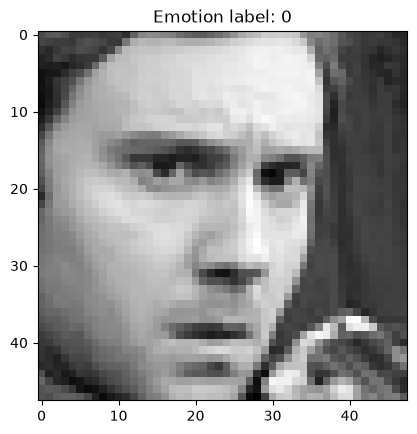

In [11]:
sample = df.iloc[0]
pixels = np.array(sample["pixels"].split(), dtype="int")
print("shape قبل از reshape:", pixels.shape)

image = pixels.reshape(48, 48)
print("shape بعد از reshape:", image.shape)

plt.imshow(image, cmap="gray")
plt.title(f"Emotion label: {sample['emotion']}")
plt.show()


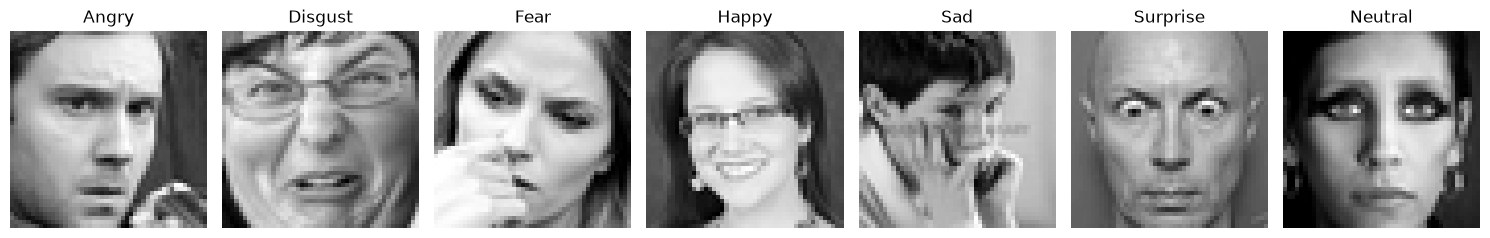

In [12]:
emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

fig, axes = plt.subplots(1, 7, figsize=(15, 3))

for emotion_num, emotion_name in emotion_labels.items():
    sample_row = df[df["emotion"] == emotion_num].iloc[0]
    pixels = np.array(sample_row["pixels"].split(), dtype="int")
    image = pixels.reshape(48, 48)
    axes[emotion_num].imshow(image, cmap="gray")
    axes[emotion_num].set_title(emotion_name)
    axes[emotion_num].axis("off")

plt.tight_layout()
plt.show()


In [13]:
print(df["Usage"].value_counts())

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [14]:
def preprocess_row(pixel_str):
    pixels = np.array(pixel_str.split(), dtype="float32")
    image = pixels.reshape(48,48,1)
    image = image / 255.0
    return image



X_all = np.stack(df["pixels"].apply(preprocess_row))
Y_all = df["emotion"].values


print("X_all shape", X_all.shape)
print("Y_all shape", Y_all.shape)




X_all shape (35887, 48, 48, 1)
Y_all shape (35887,)


In [15]:
train_df = df[df["Usage"]== "Training"]
val_df = df[df["Usage"] == "PublicTest"]
test_df = df[df["Usage"] == "PrivateTest"]

print ("train df", train_df.shape)
print ("val df", val_df.shape)
print ("test df", test_df.shape)

train df (28709, 3)
val df (3589, 3)
test df (3589, 3)


In [16]:
x_train = np.stack(train_df["pixels"].apply(preprocess_row))
y_train = train_df["emotion"].values

x_val = np.stack(val_df["pixels"].apply(preprocess_row))
y_val = val_df["emotion"].values


x_test = np.stack(test_df["pixels"].apply(preprocess_row))
y_test = test_df["emotion"].values

print("x train shape:" ,x_train.shape,"y train shape:" , y_train.shape )
print("x validation shape:" ,x_val.shape,"y validation shape:" , y_val.shape )
print("x test shape:" ,x_test.shape,"y test shape:" , y_test.shape )




x train shape: (28709, 48, 48, 1) y train shape: (28709,)
x validation shape: (3589, 48, 48, 1) y validation shape: (3589,)
x test shape: (3589, 48, 48, 1) y test shape: (3589,)


In [17]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape = (48,48,1)),
    layers.Conv2D(32,(3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation = "relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.5),
    layers.Dense(7,activation = "softmax")

])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 839,047 (3.20 MB)

 Trainable params: 839,047 (3.20 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    x_train, y_train,
    validation_data = (x_val, y_val),
    epochs = 30,
    batch_size = 64,
    callbacks = [early_stop]

)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.3287 - loss: 1.6898 - val_accuracy: 0.4324 - val_loss: 1.5118
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.4198 - loss: 1.5054 - val_accuracy: 0.4561 - val_loss: 1.4105
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4567 - loss: 1.4269 - val_accuracy: 0.4812 - val_loss: 1.3493
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.4803 - loss: 1.3585 - val_accuracy: 0.4987 - val_loss: 1.3221
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.4961 - loss: 1.3186 - val_accuracy: 0.5079 - val_loss: 1.2887
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 47ms/step - accuracy: 0.5133 - loss: 1.2772 - val_accuracy: 0.5046 - val_loss: 1.2790
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5274 - loss: 1.2411 - val_accuracy: 0.5196 - val_loss: 1.2550
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5454 - loss: 1.1984 - 

In [22]:
model.save("facemood_model.keras")

In [23]:
loss, acc = model.evaluate(x_val, y_val)
print("val_loss:", loss, "val_accuracy:", acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5352 - loss: 1.2239
val_loss: 1.2239457368850708 val_accuracy: 0.5352466106414795


In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print ("test loss", test_loss, " test accuracy", test_acc)

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5272 - loss: 1.2247
test loss 1.2246652841567993  test accuracy 0.5271663665771484


In [25]:
y_predict_probs = model.predict(x_test)
y_predict = np.argmax(y_predict_probs, axis=1)
print(y_predict[:10])
print(y_test[:10])

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[2 4 2 4 4 0 4 3 0 4]
[0 5 6 4 2 0 4 3 0 3]


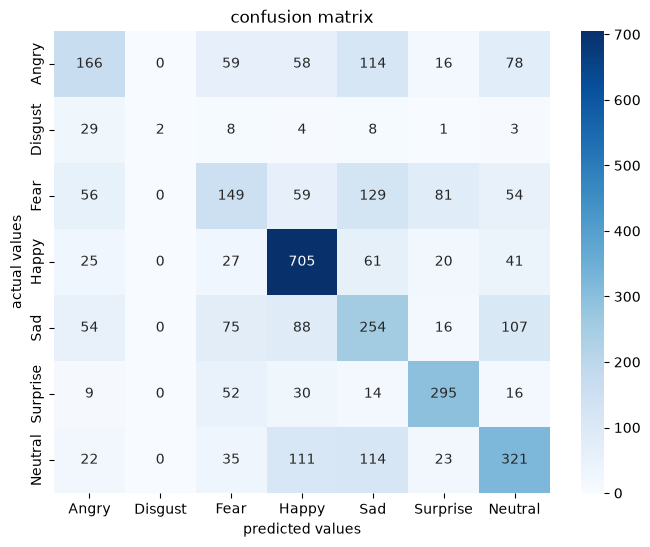

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns 

cm = confusion_matrix(y_test, y_predict)

plt.figure( figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(emotion_labels.values()), yticklabels=list(emotion_labels.values()))

plt.xlabel("predicted values")
plt.ylabel("actual values")
plt.title("confusion matrix")
plt.show()
